# HAM10000 — Clasificación comparativa

Entrena EfficientNet-B0 bajo 4 escenarios de augmentación sintética y compara resultados.

| Escenario | Train mel | Train nv | Pregunta |
|---|---|---|---|
| `real_only` | ~800 reales | ~4700 reales | Baseline |
| `real_balanced` | 800 reales + ~3900 sint. | ~4700 reales | ¿El sintético ayuda a balancear? |
| `real_2x` | 800 reales + 800 sint. | ~4700 reales | ¿Doblar la minoría mejora? |
| `synthetic_only` | ~800 sint. (sin reales) | ~4700 reales | ¿Las sintéticas reemplazan a las reales? |

El test set es **siempre solo imágenes reales**.

Cada run genera un directorio `YYYYMMDD_HHMMSS_<escenario>/` con `config.json`,
`test_metrics.json`, `history.json`, `best_model.pt`, y plots.
Si la sesión se interrumpe, el notebook retoma desde el último checkpoint.

| Hardware | Tiempo estimado por escenario |
|---|---|
| Google Colab T4 (16 GB) | ~60–90 min |
| Google Colab L4 (24 GB) | ~40–60 min |
| CPU | ~4–6 h |

**Prerequisito (Colab):** `classification_data.zip` en Drive  
→ `python scripts/augmentation/prepare_for_colab_classification.py`  
→ subir a `Mi unidad/ham10000-augmentation/classification_data.zip`

**Prerequisito (Colab):** imágenes sintéticas en Drive  
→ `Mi unidad/ham10000-augmentation/synthetic/textual_inversion/` y `img2img/`

In [1]:
# Detectar entorno
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import torch

def get_device():
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'CUDA GPU: {name}  ({vram:.1f} GB)')
        return torch.device('cuda'), vram
    if torch.backends.mps.is_available():
        print('Apple Silicon MPS')
        return torch.device('mps'), 0
    print('Sin GPU — usando CPU')
    return torch.device('cpu'), 0

DEVICE, VRAM_GB = get_device()
print(f'IN_COLAB={IN_COLAB}  device={DEVICE}')

CUDA GPU: Tesla T4  (15.6 GB)
IN_COLAB=True  device=cuda


In [2]:
from pathlib import Path

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT  = Path('/content/drive/MyDrive/ham10000-augmentation')
    ZIP_PATH    = DRIVE_ROOT / 'classification_data.zip'
    IMAGES_DIR  = Path('/content/images')
    SPLITS_DIR  = Path('/content/splits')
    SYNTH_DIR   = DRIVE_ROOT / 'synthetic'
    EXP_ROOT    = DRIVE_ROOT / 'experiments'
else:
    PROJECT_ROOT = Path.cwd()
    ZIP_PATH     = PROJECT_ROOT / 'data/processed/classification_data.zip'
    IMAGES_DIR   = PROJECT_ROOT / 'data/raw/ham10000'
    SPLITS_DIR   = PROJECT_ROOT / 'data/processed/splits'
    SYNTH_DIR    = PROJECT_ROOT / 'data/synthetic'
    EXP_ROOT     = PROJECT_ROOT / 'experiments'

EXP_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Splits:       {SPLITS_DIR}')
print(f'Imágenes:     {IMAGES_DIR}')
print(f'Sintéticas:   {SYNTH_DIR}')
print(f'Experimentos: {EXP_ROOT}')

Mounted at /content/drive
Splits:       /content/splits
Imágenes:     /content/images
Sintéticas:   /content/drive/MyDrive/ham10000-augmentation/synthetic
Experimentos: /content/drive/MyDrive/ham10000-augmentation/experiments


In [3]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import timm; print(f'timm {timm.__version__}')
except ImportError:
    print('Instalando timm...'); pip_install('timm'); import timm

try:
    import sklearn; print(f'scikit-learn {sklearn.__version__}')
except ImportError:
    pip_install('scikit-learn'); import sklearn

timm 1.0.26
scikit-learn 1.6.1


In [6]:
# Extraer ZIP con imágenes reales (solo en Colab, idempotente)
import zipfile

if IN_COLAB:
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)
    SPLITS_DIR.mkdir(parents=True, exist_ok=True)

    jpg_count = len(list(IMAGES_DIR.glob('*.jpg')))
    if jpg_count < 100:
        assert ZIP_PATH.exists(), (
            f'ZIP no encontrado: {ZIP_PATH}\n'
            'Ejecuta: python scripts/augmentation/prepare_for_colab_classification.py'
        )
        print('Extrayendo imágenes del ZIP...')
        with zipfile.ZipFile(ZIP_PATH) as zf:
            for m in zf.infolist():
                data = zf.read(m.filename)
                if m.filename.startswith('images/') and m.filename.endswith('.jpg'):
                    (IMAGES_DIR / Path(m.filename).name).write_bytes(data)
                elif m.filename.startswith('splits/') and m.filename.endswith('.csv'):
                    (SPLITS_DIR / Path(m.filename).name).write_bytes(data)
        print('Listo')
    else:
        print(f'Imágenes ya extraídas ({jpg_count} archivos)')

Extrayendo imágenes del ZIP...
Listo


## Estado de escenarios

Ejecuta esta celda para ver el progreso sin cargar modelos.

In [7]:
import json

SCENARIOS = ['real_only', 'real_balanced', 'real_2x', 'synthetic_only']

def find_run_dir(sc):
    """Devuelve el Path del run activo o más reciente para un escenario, o None."""
    pointer = EXP_ROOT / f'{sc}_current.txt'
    if pointer.exists():
        return EXP_ROOT / pointer.read_text().strip()
    completed = sorted([d for d in EXP_ROOT.glob(f'*_{sc}') if (d / 'test_metrics.json').exists()])
    return completed[-1] if completed else None

print('Estado de escenarios:')
for sc in SCENARIOS:
    pointer = EXP_ROOT / f'{sc}_current.txt'
    run_dir = find_run_dir(sc)
    if run_dir is None:
        print(f'  {sc}: pendiente')
    elif (run_dir / 'test_metrics.json').exists():
        m = json.loads((run_dir / 'test_metrics.json').read_text())
        print(f'  {sc}: completado ({run_dir.name})  AUC={m["auc"]}  Recall_mel={m["recall_mel"]}  F1_mel={m["f1_mel"]}')
    else:
        ckpt   = run_dir / 'checkpoint_last.pt'
        status = 'retomable (checkpoint existe)' if ckpt.exists() else 'iniciado'
        print(f'  {sc}: {status} ({run_dir.name})')

synth_ti  = list((SYNTH_DIR / 'textual_inversion').glob('*.jpg')) if (SYNTH_DIR / 'textual_inversion').exists() else []
synth_i2i = list((SYNTH_DIR / 'img2img').glob('*.jpg')) if (SYNTH_DIR / 'img2img').exists() else []
print(f'\nImágenes sintéticas: TI={len(synth_ti)}  Img2Img={len(synth_i2i)}  Total={len(synth_ti)+len(synth_i2i)}')

Estado de escenarios:
  real_only: pendiente
  real_balanced: pendiente
  real_2x: pendiente
  synthetic_only: pendiente

Imágenes sintéticas: TI=4500  Img2Img=2403  Total=6903


## Hiperparámetros

In [8]:
EPOCHS      = 15
LR          = 1e-4
SEED        = 42

if DEVICE.type == 'cuda':
    BATCH_SIZE  = 64 if VRAM_GB >= 40 else 32
    NUM_WORKERS = 2
else:
    BATCH_SIZE  = 8
    NUM_WORKERS = 0

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'EPOCHS={EPOCHS}  LR={LR}  BATCH_SIZE={BATCH_SIZE}  NUM_WORKERS={NUM_WORKERS}')

EPOCHS=15  LR=0.0001  BATCH_SIZE=32  NUM_WORKERS=2


## Utilidades de dataset

In [9]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class FlatDataset(Dataset):
    """Dataset from a list of (abs_path, label) tuples."""
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

    def class_weights(self):
        labels  = np.array([lbl for _, lbl in self.samples])
        counts  = np.bincount(labels)
        w_class = 1.0 / counts.astype(float)
        return torch.tensor([w_class[lbl] for _, lbl in self.samples], dtype=torch.float)


def make_loader(samples, transform, weighted=False):
    ds  = FlatDataset(samples, transform)
    pin = DEVICE.type == 'cuda'
    if weighted:
        sampler = WeightedRandomSampler(ds.class_weights(), len(ds), replacement=True)
        return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                         num_workers=NUM_WORKERS, pin_memory=pin)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=NUM_WORKERS, pin_memory=pin)


def resolve_path(rel_path):
    if IN_COLAB:
        return IMAGES_DIR / Path(rel_path).name
    return PROJECT_ROOT / rel_path


def load_splits():
    def read(csv_path, label_filter=None):
        df = pd.read_csv(csv_path)
        if label_filter is not None:
            df = df[df['label'] == label_filter]
        return [(resolve_path(row['image_path']), int(row['label'])) for _, row in df.iterrows()]

    train_nv  = read(SPLITS_DIR / 'train.csv', label_filter=0)
    train_mel = read(SPLITS_DIR / 'train.csv', label_filter=1)
    val       = read(SPLITS_DIR / 'val.csv')
    test      = read(SPLITS_DIR / 'test.csv')
    print(f'Splits cargados — train nv:{len(train_nv)} mel:{len(train_mel)} | val:{len(val)} | test:{len(test)}')
    return train_nv, train_mel, val, test


def synth_samples(n=None, seed=SEED):
    """Lista de (Path, 1) de imágenes sintéticas de melanoma, orden reproducible."""
    paths = (
        list((SYNTH_DIR / 'textual_inversion').glob('*.jpg')) +
        list((SYNTH_DIR / 'img2img').glob('*.jpg'))
    )
    random.Random(seed).shuffle(paths)
    if n is not None:
        paths = paths[:n]
    return [(p, 1) for p in paths]


print('Utilidades de dataset listas')

Utilidades de dataset listas


## Modelo y loop de entrenamiento (con resume)

In [10]:
import time
import timm
import torch.nn as nn
from datetime import datetime, timezone
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


def build_model():
    return timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)


def _eval_loop(model, loader, criterion):
    model.eval()
    loss_sum, total = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            loss_sum += loss.item() * len(labels)
            total    += len(labels)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
    return {
        'loss':       round(loss_sum / total, 4),
        'f1_mel':     round(f1_score(all_labels, all_preds, pos_label=1, zero_division=0), 4),
        'recall_mel': round(recall_score(all_labels, all_preds, pos_label=1, zero_division=0), 4),
        'auc':        round(roc_auc_score(all_labels, all_probs), 4),
    }


def run_scenario(name, train_samples, val_samples, test_samples):
    # Buscar o crear run_id único para este escenario
    pointer_file = EXP_ROOT / f'{name}_current.txt'
    if pointer_file.exists():
        run_id = pointer_file.read_text().strip()
    else:
        run_id = f'{datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")}_{name}'
        pointer_file.write_text(run_id)

    run_dir     = EXP_ROOT / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    done_marker = run_dir / 'test_metrics.json'
    ckpt_path   = run_dir / 'checkpoint_last.pt'

    # Saltar si ya está completo
    if done_marker.exists():
        metrics = json.loads(done_marker.read_text())
        pointer_file.unlink(missing_ok=True)
        print(f'[{name}] Ya completado ({run_id})')
        print(f'  AUC={metrics["auc"]}  Recall_mel={metrics["recall_mel"]}  F1_mel={metrics["f1_mel"]}')
        return metrics

    n_nv  = sum(1 for _, l in train_samples if l == 0)
    n_mel = sum(1 for _, l in train_samples if l == 1)
    print(f'\n{"="*60}')
    print(f'Escenario: {name} ({run_id})')
    print(f'train nv={n_nv} mel={n_mel}  |  val={len(val_samples)} test={len(test_samples)}')
    print(f'{"="*60}')

    # Guardar config al inicio (misma estructura que baseline)
    if not (run_dir / 'config.json').exists():
        config = {
            'run_id':     run_id,
            'scenario':   name,
            'model':      'efficientnet_b0',
            'pretrained': True,
            'epochs':     EPOCHS,
            'batch_size': BATCH_SIZE,
            'lr':         LR,
            'seed':       SEED,
            'train_nv':   n_nv,
            'train_mel':  n_mel,
            'started_at': datetime.now(timezone.utc).isoformat(),
        }
        (run_dir / 'config.json').write_text(json.dumps(config, indent=2))

    train_loader = make_loader(train_samples, TRAIN_TF, weighted=True)
    val_loader   = make_loader(val_samples,   EVAL_TF)
    test_loader  = make_loader(test_samples,  EVAL_TF)

    model     = build_model().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    start_epoch = 1
    best_f1     = 0.0
    history     = []

    # Reanudar desde checkpoint si existe
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_f1     = ckpt['best_f1']
        history     = ckpt['history']
        print(f'Retomando desde epoch {start_epoch}  (best_f1={best_f1:.4f})')

    for epoch in range(start_epoch, EPOCHS + 1):
        t0 = time.time()
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'[{name}] Epoch {epoch:02d}/{EPOCHS}', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)
            pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.3f}')

        scheduler.step()
        val_m   = _eval_loop(model, val_loader, criterion)
        elapsed = time.time() - t0

        row = {
            'epoch':      epoch,
            'train_loss': round(train_loss / total, 4),
            'train_acc':  round(correct / total, 4),
            **{f'val_{k}': v for k, v in val_m.items()},
            'elapsed_s':  round(elapsed, 1),
        }
        history.append(row)
        print(f'  Epoch {epoch:02d}/{EPOCHS} | loss={train_loss/total:.4f} | '
              f'val_f1_mel={val_m["f1_mel"]:.3f} val_auc={val_m["auc"]:.3f} | {elapsed:.0f}s')

        if val_m['f1_mel'] >= best_f1:
            best_f1 = val_m['f1_mel']
            torch.save(model.state_dict(), run_dir / 'best_model.pt')

        # Checkpoint tras cada epoch para permitir resume
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_f1':   best_f1,
            'history':   history,
        }, ckpt_path)

    (run_dir / 'history.json').write_text(json.dumps(history, indent=2))

    # Evaluación final en test
    model.load_state_dict(torch.load(run_dir / 'best_model.pt', map_location=DEVICE))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.cpu().tolist())

    report = classification_report(all_labels, all_preds, target_names=['nv', 'mel'], output_dict=True)
    auc    = roc_auc_score(all_labels, all_probs)

    # test_metrics.json: misma estructura que el baseline local
    metrics = {
        'auc':           round(auc, 4),
        'f1_mel':        round(report['mel']['f1-score'], 4),
        'recall_mel':    round(report['mel']['recall'], 4),
        'precision_mel': round(report['mel']['precision'], 4),
        'f1_nv':         round(report['nv']['f1-score'], 4),
        'accuracy':      round(report['accuracy'], 4),
    }
    done_marker.write_text(json.dumps(metrics, indent=2))
    (run_dir / 'classification_report.json').write_text(json.dumps(report, indent=2))

    # Actualizar config con finished_at y métricas finales (misma estructura que baseline)
    cfg = json.loads((run_dir / 'config.json').read_text())
    cfg['finished_at']  = datetime.now(timezone.utc).isoformat()
    cfg['test_metrics'] = metrics
    (run_dir / 'config.json').write_text(json.dumps(cfg, indent=2))

    # Plots
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['nv', 'mel']).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    fig.tight_layout(); fig.savefig(run_dir / 'confusion_matrix.png', dpi=150); plt.close(fig)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {name}'); ax.legend()
    fig.tight_layout(); fig.savefig(run_dir / 'roc_curve.png', dpi=150); plt.close(fig)

    # Limpiar checkpoint y pointer una vez completado
    ckpt_path.unlink(missing_ok=True)
    pointer_file.unlink(missing_ok=True)

    print(f'\n[{name}] COMPLETADO ({run_id})')
    print(f'  AUC={metrics["auc"]}  Recall_mel={metrics["recall_mel"]}  F1_mel={metrics["f1_mel"]}')
    return metrics


print('Loop de entrenamiento listo')

Loop de entrenamiento listo


## Cargar splits

In [11]:
train_nv, train_mel, val_samples, test_samples = load_splits()

all_synth = synth_samples()
print(f'Sintéticas disponibles: {len(all_synth)}')

n_to_balance = max(0, len(train_nv) - len(train_mel))
n_2x         = len(train_mel)
print(f'\nPara real_balanced: añadir {n_to_balance} sint. (mel {len(train_mel)} → {len(train_mel)+n_to_balance})')
print(f'Para real_2x:       añadir {n_2x} sint. (mel {len(train_mel)} → {len(train_mel)*2})')
print(f'Para synthetic_only: {n_2x} sint. reemplazan {len(train_mel)} reales')

Splits cargados — train nv:4675 mel:801 | val:1171 | test:1171
Sintéticas disponibles: 6903

Para real_balanced: añadir 3874 sint. (mel 801 → 4675)
Para real_2x:       añadir 801 sint. (mel 801 → 1602)
Para synthetic_only: 801 sint. reemplazan 801 reales


## Escenario 1 — `real_only` (baseline)

Solo imágenes reales. Desbalance original ~6:1 (nv:mel).

In [12]:
results_real_only = run_scenario(
    name          = 'real_only',
    train_samples = train_nv + train_mel,
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: real_only (20260514_131247_real_only)
train nv=4675 mel=801  |  val=1171 test=1171


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

[real_only] Epoch 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.8995 | val_f1_mel=0.510 val_auc=0.881 | 76s


...

[real_only] Epoch 14/15:   0%|          | 0/172 [00:00<?, ?it/s]

  Epoch 14/15 | loss=0.0653 | val_f1_mel=0.656 val_auc=0.931 | 76s


[real_only] Epoch 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 15/15 | loss=0.0727 | val_f1_mel=0.648 val_auc=0.934 | 79s

[real_only] COMPLETADO (20260514_131247_real_only)
  AUC=0.9227  Recall_mel=0.6855  F1_mel=0.6337


## Escenario 2 — `real_balanced`

Imágenes reales + sintéticas de melanoma hasta que `mel ≈ nv` en entrenamiento.

In [14]:
# Copiar sintéticas de Drive a disco local (una vez por sesión)
if IN_COLAB:
    import shutil
    LOCAL_SYNTH = Path('/content/synthetic')
    if not LOCAL_SYNTH.exists():
        print('Copiando sintéticas de Drive a /content/... (2-3 min)')
        shutil.copytree(str(SYNTH_DIR), str(LOCAL_SYNTH))
        print(f'Listo: {len(list(LOCAL_SYNTH.glob("**/*.jpg")))} imágenes')
    SYNTH_DIR = LOCAL_SYNTH
    print(f'SYNTH_DIR → {SYNTH_DIR}')

Copiando sintéticas de Drive a /content/... (2-3 min)
Listo: 6903 imágenes
SYNTH_DIR → /content/synthetic


In [15]:
synth_balance = synth_samples(n=n_to_balance)

results_balanced = run_scenario(
    name          = 'real_balanced',
    train_samples = train_nv + train_mel + synth_balance,
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: real_balanced (20260514_133441_real_balanced)
train nv=4675 mel=4675  |  val=1171 test=1171


[real_balanced] Epoch 01/15:   0%|          | 0/293 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.4019 | val_f1_mel=0.562 val_auc=0.899 | 107s


[real_balanced] Epoch 02/15:   0%|          | 0/293 [00:00<?, ?it/s]

  Epoch 02/15 | loss=0.1658 | val_f1_mel=0.608 val_auc=0.914 | 109s


...

  Epoch 13/15 | loss=0.0367 | val_f1_mel=0.617 val_auc=0.929 | 122s


[real_balanced] Epoch 14/15:   0%|          | 0/293 [00:00<?, ?it/s]

  Epoch 14/15 | loss=0.0308 | val_f1_mel=0.630 val_auc=0.927 | 114s


[real_balanced] Epoch 15/15:   0%|          | 0/293 [00:00<?, ?it/s]

  Epoch 15/15 | loss=0.0287 | val_f1_mel=0.641 val_auc=0.931 | 110s

[real_balanced] COMPLETADO (20260514_133441_real_balanced)
  AUC=0.9257  Recall_mel=0.6855  F1_mel=0.6412


## Escenario 3 — `real_2x`

Imágenes reales + misma cantidad de sintéticas que mel reales (dobla la clase minoritaria).

In [16]:
synth_2x = synth_samples(n=n_2x)

results_2x = run_scenario(
    name          = 'real_2x',
    train_samples = train_nv + train_mel + synth_2x,
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: real_2x (20260514_145950_real_2x)
train nv=4675 mel=1602  |  val=1171 test=1171


[real_2x] Epoch 01/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.7347 | val_f1_mel=0.518 val_auc=0.878 | 78s


[real_2x] Epoch 02/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

[real_2x] Epoch 14/15:   0%|          | 0/197 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 14/15 | loss=0.0605 | val_f1_mel=0.663 val_auc=0.933 | 81s


[real_2x] Epoch 15/15:   0%|          | 0/197 [00:00<?, ?it/s]

  Epoch 15/15 | loss=0.0637 | val_f1_mel=0.667 val_auc=0.931 | 81s

[real_2x] COMPLETADO (20260514_145950_real_2x)
  AUC=0.924  Recall_mel=0.6792  F1_mel=0.6243


## Escenario 4 — `synthetic_only`

Las imágenes reales de melanoma del entrenamiento se reemplazan por sintéticas del mismo tamaño. Nevus sigue siendo real.

In [17]:
synth_replace = synth_samples(n=n_2x)

results_synth_only = run_scenario(
    name          = 'synthetic_only',
    train_samples = train_nv + synth_replace,
    val_samples   = val_samples,
    test_samples  = test_samples,
)


Escenario: synthetic_only (20260514_152510_synthetic_only)
train nv=4675 mel=801  |  val=1171 test=1171


[synthetic_only] Epoch 01/15:   0%|          | 0/172 [00:00<?, ?it/s]

  Epoch 01/15 | loss=0.2049 | val_f1_mel=0.162 val_auc=0.695 | 66s


[synthetic_only] Epoch 02/15:   0%|          | 0/172 [00:00<?, ?it/s]

  Epoch 02/15 | loss=0.0486 | val_f1_mel=0.081 val_auc=0.747 | 67s


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Epoch 14/15 | loss=0.0026 | val_f1_mel=0.025 val_auc=0.773 | 77s


[synthetic_only] Epoch 15/15:   0%|          | 0/172 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c473877cae0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    
if w.is_alive():Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

      self._shutdown_workers()  
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
 ^ ^^ ^ ^ ^^ ^^ ^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'
^    ^  ^ ^^ ^ ^^ ^^ 
^^  File "/u

  Epoch 15/15 | loss=0.0014 | val_f1_mel=0.000 val_auc=0.773 | 73s

[synthetic_only] COMPLETADO (20260514_152510_synthetic_only)
  AUC=0.6864  Recall_mel=0.0881  F1_mel=0.1421


## Comparación de escenarios

In [18]:
# Carga el run más reciente de cada escenario (funciona aunque algunos no se hayan corrido en esta sesión)
all_results = {}
run_dirs    = {}
for sc in SCENARIOS:
    run_dir = find_run_dir(sc)
    if run_dir and (run_dir / 'test_metrics.json').exists():
        all_results[sc] = json.loads((run_dir / 'test_metrics.json').read_text())
        run_dirs[sc]    = run_dir
    else:
        print(f'[{sc}] no completado — omitido de la comparación')

if all_results:
    rows = []
    for sc, m in all_results.items():
        cfg_path    = run_dirs[sc] / 'config.json'
        cfg         = json.loads(cfg_path.read_text()) if cfg_path.exists() else {}
        rows.append({
            'Escenario':     sc,
            'Run ID':        run_dirs[sc].name,
            'Train mel':     cfg.get('train_mel', '?'),
            'AUC':           m['auc'],
            'Recall mel':    m['recall_mel'],
            'F1 mel':        m['f1_mel'],
            'Precision mel': m['precision_mel'],
            'Accuracy':      m['accuracy'],
        })
    df = pd.DataFrame(rows).set_index('Escenario')
    print(df.to_string())

    comparison_path = EXP_ROOT / 'comparison.json'
    comparison_path.write_text(json.dumps(all_results, indent=2))
    print(f'\nComparación guardada en {comparison_path}')

                                        Run ID  Train mel     AUC  Recall mel  F1 mel  Precision mel  Accuracy
Escenario                                                                                                     
real_only            20260514_131247_real_only        801  0.9227      0.6855  0.6337         0.5892    0.8924
real_balanced    20260514_133441_real_balanced       4675  0.9257      0.6855  0.6412         0.6022    0.8958
real_2x                20260514_145950_real_2x       1602  0.9240      0.6792  0.6243         0.5775    0.8890
synthetic_only  20260514_152510_synthetic_only        801  0.6864      0.0881  0.1421         0.3684    0.8557

Comparación guardada en /content/drive/MyDrive/ham10000-augmentation/experiments/comparison.json


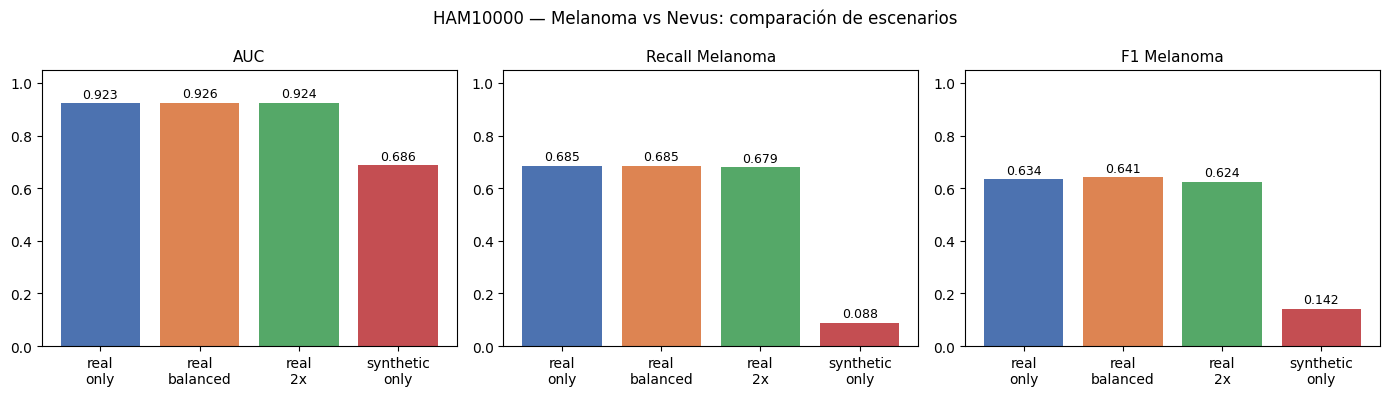

Plot guardado en /content/drive/MyDrive/ham10000-augmentation/experiments/comparison_plot.png


In [19]:
if len(all_results) >= 2:
    sc_list  = list(all_results.keys())
    sc_labels = [s.replace('_', '\n') for s in sc_list]
    colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (metric, title) in zip(axes, [('auc', 'AUC'), ('recall_mel', 'Recall Melanoma'), ('f1_mel', 'F1 Melanoma')]):
        values = [all_results[sc][metric] for sc in sc_list]
        bars   = ax.bar(sc_labels, values, color=colors[:len(sc_list)])
        ax.set_ylim(0, 1.05)
        ax.set_title(title, fontsize=11)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    fig.suptitle('HAM10000 — Melanoma vs Nevus: comparación de escenarios', fontsize=12)
    fig.tight_layout()
    fig.savefig(EXP_ROOT / 'comparison_plot.png', dpi=150)
    plt.show()
    print(f'Plot guardado en {EXP_ROOT}/comparison_plot.png')